In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.eda_utils import *

df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [3]:
df.shape

(10000, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [5]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [7]:
(df.isnull().mean() * 100).sort_values(ascending=False)

CustomerID             0.0
Age                    0.0
Gender                 0.0
Province               0.0
VehicleType            0.0
AnnualIncome           0.0
RiskScore              0.0
AnnualPremium          0.0
Deductible             0.0
NCD                    0.0
PastClaims             0.0
Claimed                0.0
ClaimAmount            0.0
TotalPremium           0.0
TotalClaims            0.0
CoverType              0.0
AutoMake               0.0
VehicleModel           0.0
CustomValueEstimate    0.0
ZipCode                0.0
TransactionDate        0.0
dtype: float64

In [8]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

In [9]:
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [10]:
df[["TotalPremium", "TotalClaims", "LossRatio", "Margin"]].head()

,TotalPremium,TotalClaims,LossRatio,Margin
0,2346,0.0,0.000000,2346.0
1,2334,9883.0,4.234362,-7549.0
2,1697,0.0,0.000000,1697.0
3,2370,12134.0,5.119831,-9764.0
4,2582,0.0,0.000000,2582.0


In [11]:
df["LossRatio"].mean()

np.float64(0.44276983207010434)

In [12]:
df["Margin"].sum()

np.float64(11739394.0)

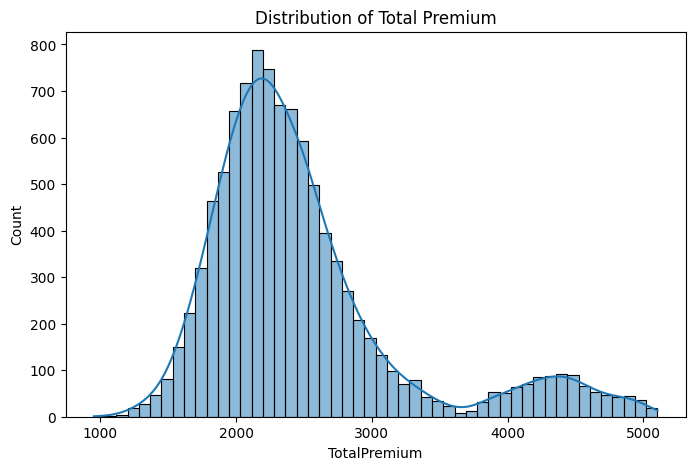

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPremium"], bins=50, kde=True)
plt.title("Distribution of Total Premium")
plt.show()

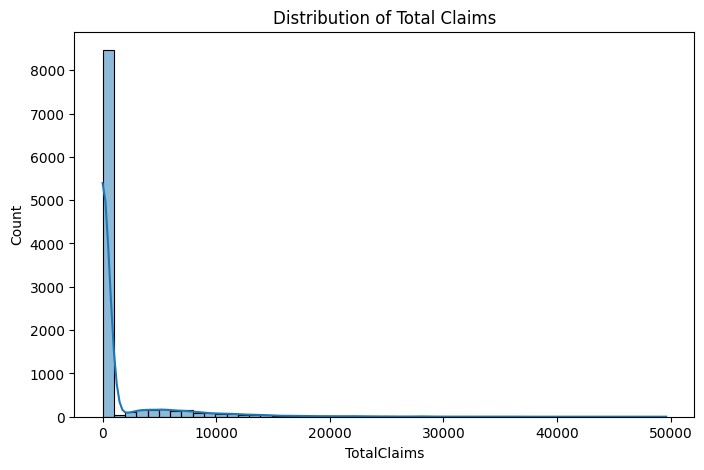

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalClaims"], bins=50, kde=True)
plt.title("Distribution of Total Claims")
plt.show()

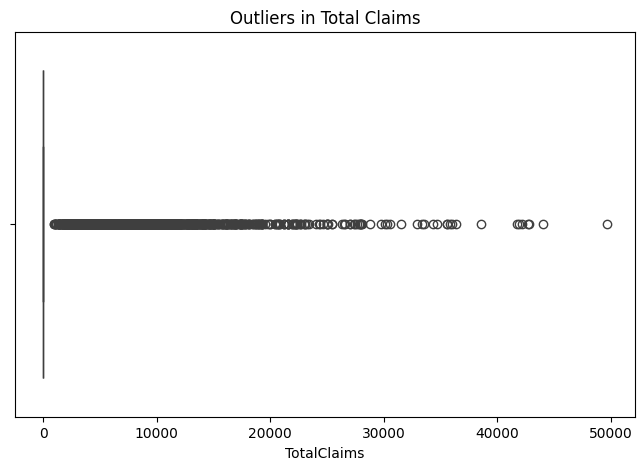

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalClaims"])
plt.title("Outliers in Total Claims")
plt.show()

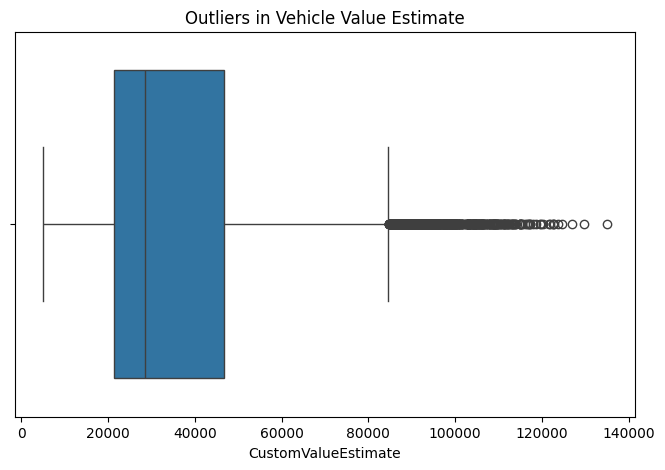

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["CustomValueEstimate"])
plt.title("Outliers in Vehicle Value Estimate")
plt.show()

In [17]:
province_risk = df.groupby("Province")[["TotalPremium", "TotalClaims", "LossRatio"]].mean().sort_values("LossRatio", ascending=False)
province_risk

,TotalPremium,TotalClaims,LossRatio
Province,,,
Somali,2521.101351,1542.730574,0.523516
Oromia,2481.464841,1333.221995,0.452680
Tigray,2475.985075,1302.407960,0.438639
Addis Ababa,2497.161200,1304.516400,0.436347
Amhara,2465.515758,1177.531266,0.395941


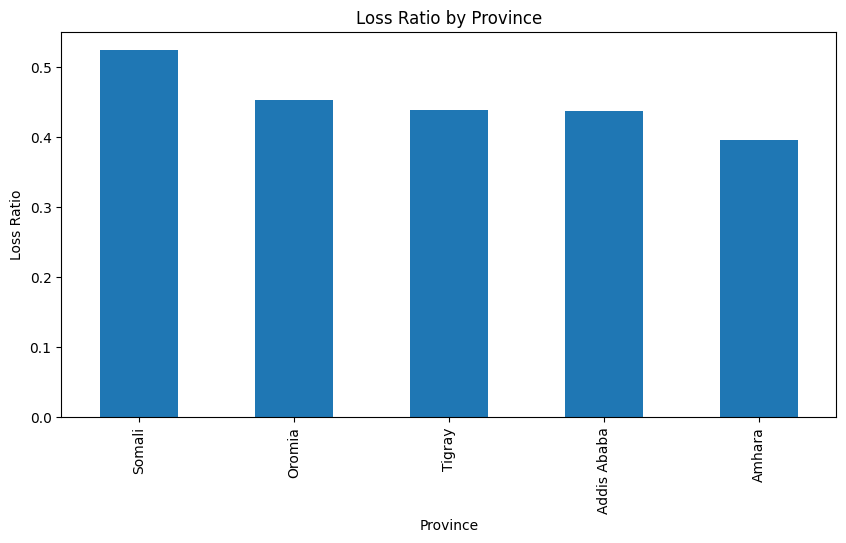

In [18]:
province_risk["LossRatio"].plot(kind="bar", figsize=(10,5), title="Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.show()

In [19]:
vehicle_risk = df.groupby("VehicleType")["LossRatio"].mean().sort_values(ascending=False)
vehicle_risk

VehicleType
Luxury       0.803672
SUV          0.499749
Hatchback    0.370846
Sedan        0.348758
Name: LossRatio, dtype: float64

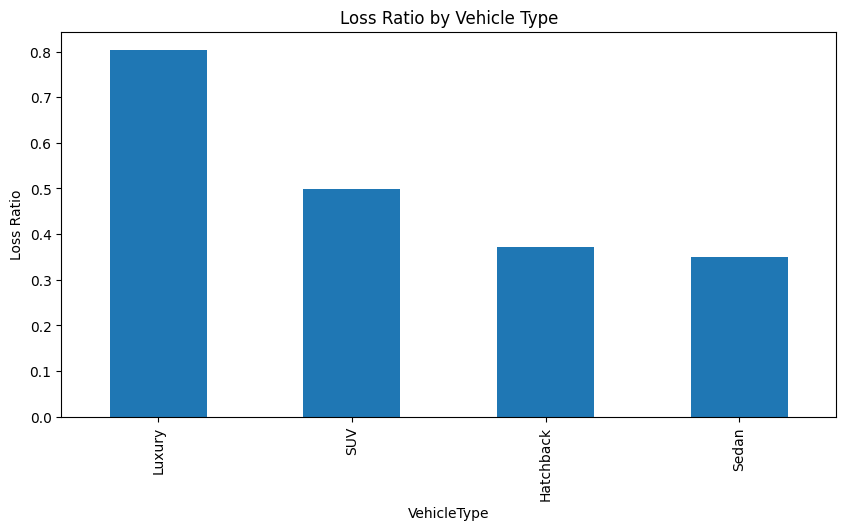

In [20]:
vehicle_risk.plot(kind="bar", figsize=(10,5), title="Loss Ratio by Vehicle Type")
plt.ylabel("Loss Ratio")
plt.show()

In [21]:
gender_risk = df.groupby("Gender")[["TotalClaims", "LossRatio"]].mean()
gender_risk

,TotalClaims,LossRatio
Gender,,
Female,1316.276761,0.447351
Male,1311.981695,0.437929


In [26]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [27]:
df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["YearMonth"] = df["TransactionDate"].dt.to_period("M")

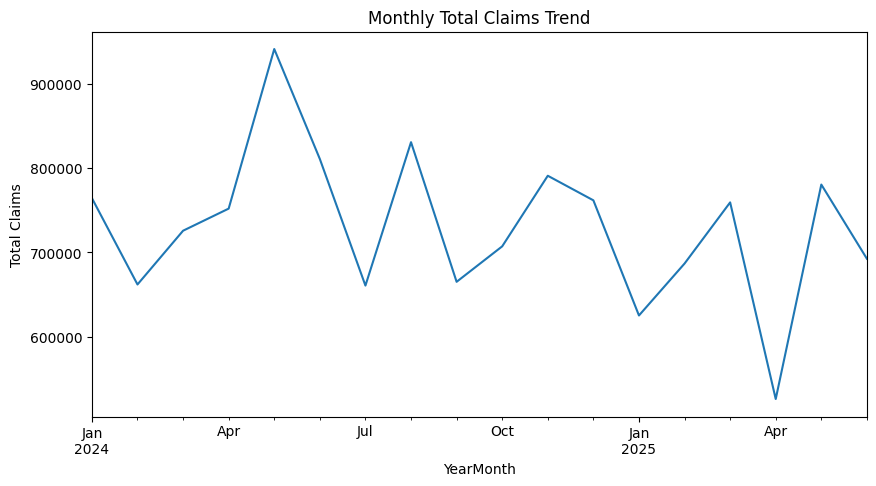

In [28]:
monthly_claims = df.groupby("YearMonth")["TotalClaims"].sum()

monthly_claims.plot(figsize=(10,5), title="Monthly Total Claims Trend")
plt.ylabel("Total Claims")
plt.show()

In [29]:
df["LossRatio"].mean()

np.float64(0.44276983207010434)

In [30]:
df["Margin"].sum()

np.float64(11739394.0)

In [31]:
province_risk = df.groupby("Province")[["TotalClaims", "LossRatio"]].mean().sort_values("LossRatio", ascending=False)
province_risk

,TotalClaims,LossRatio
Province,,
Somali,1542.730574,0.523516
Oromia,1333.221995,0.452680
Tigray,1302.407960,0.438639
Addis Ababa,1304.516400,0.436347
Amhara,1177.531266,0.395941


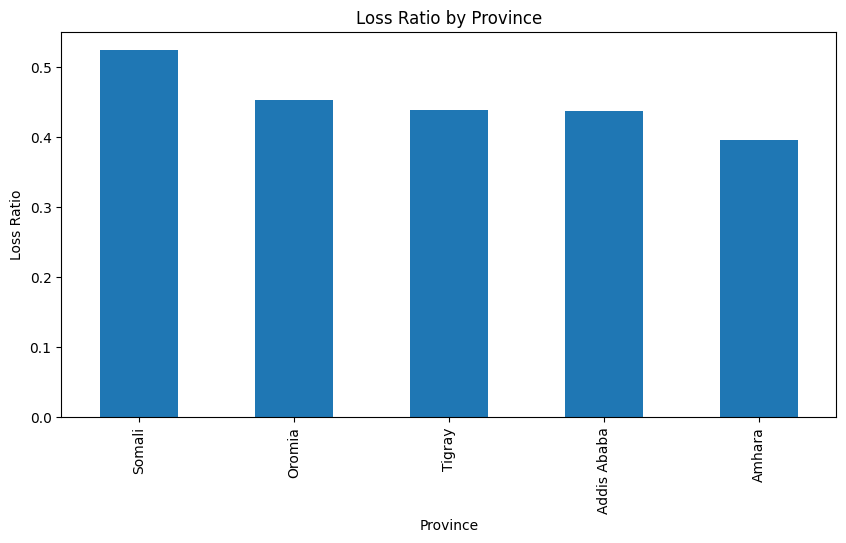

In [32]:
province_risk["LossRatio"].plot(kind="bar", figsize=(10,5), title="Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.show()

In [33]:
vehicle_risk = df.groupby("VehicleType")["LossRatio"].mean().sort_values(ascending=False)
vehicle_risk

VehicleType
Luxury       0.803672
SUV          0.499749
Hatchback    0.370846
Sedan        0.348758
Name: LossRatio, dtype: float64

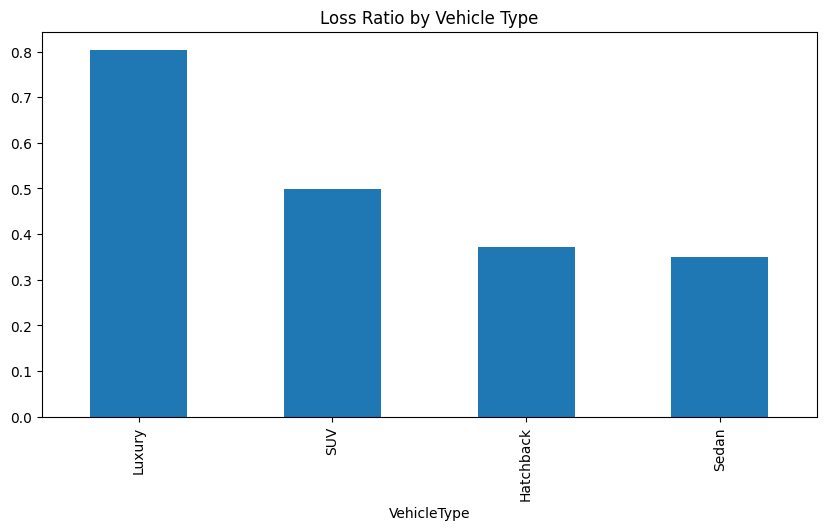

In [34]:
vehicle_risk.plot(kind="bar", figsize=(10,5), title="Loss Ratio by Vehicle Type")
plt.show()

In [35]:
df.groupby("Gender")[["TotalClaims", "LossRatio"]].mean()

,TotalClaims,LossRatio
Gender,,
Female,1316.276761,0.447351
Male,1311.981695,0.437929


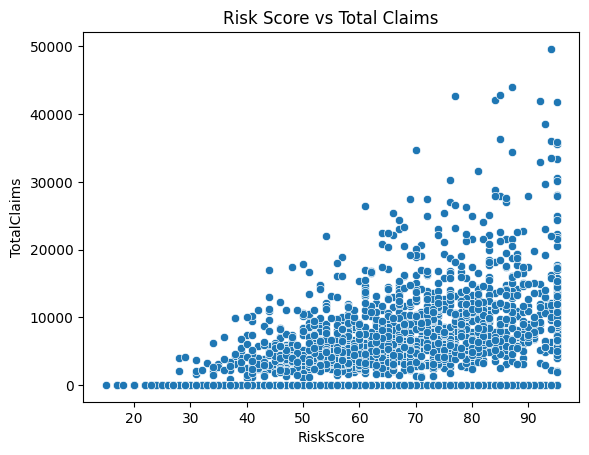

In [36]:
sns.scatterplot(data=df, x="RiskScore", y="TotalClaims")
plt.title("Risk Score vs Total Claims")
plt.show()

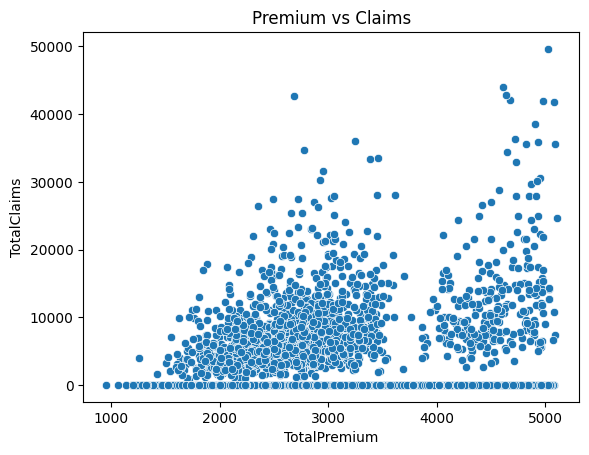

In [37]:
sns.scatterplot(data=df, x="TotalPremium", y="TotalClaims")
plt.title("Premium vs Claims")
plt.show()

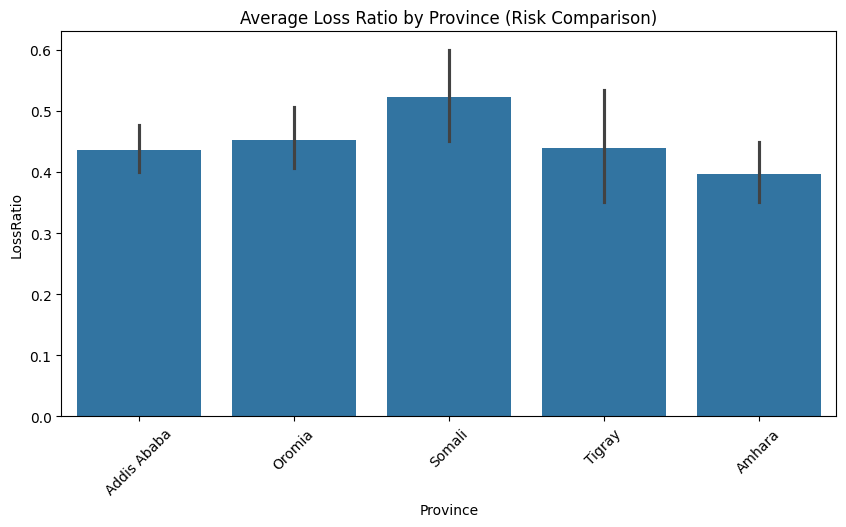

In [38]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Province", y="LossRatio")
plt.title("Average Loss Ratio by Province (Risk Comparison)")
plt.xticks(rotation=45)
plt.show()

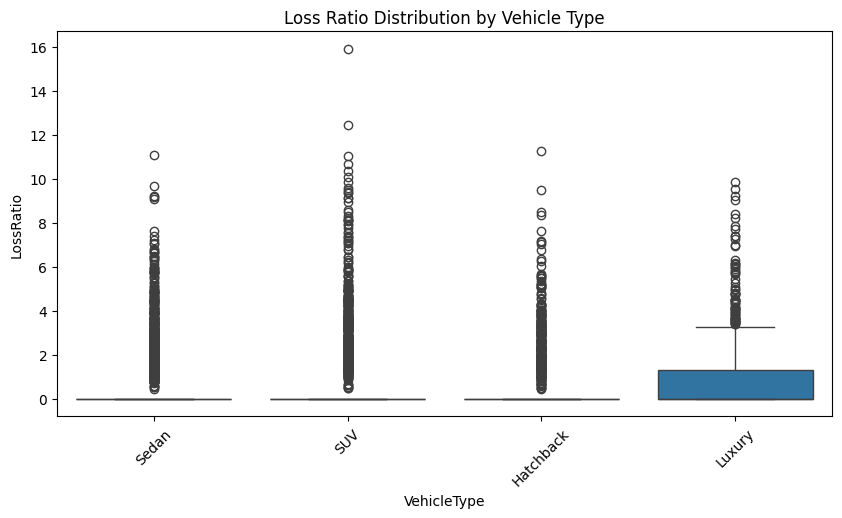

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="VehicleType", y="LossRatio")
plt.title("Loss Ratio Distribution by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

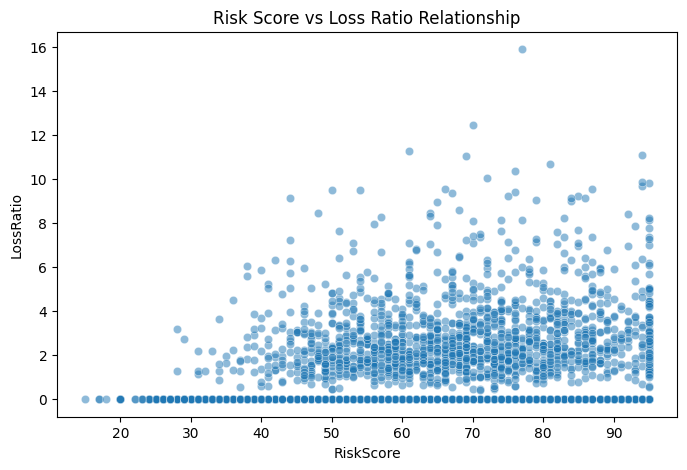

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="RiskScore", y="LossRatio", alpha=0.5)
plt.title("Risk Score vs Loss Ratio Relationship")
plt.show()